# IntroML2026 Final Project : Predicting Nuclear Waste Temperature

**Group name :** Bétonbraisé

**Authors:** Alice Verniquet and Laura Monney


# 1. Introduction

<div style="text-align: justify;">
This project aims to predict the temperature evolution around nuclear waste canisters 
using measurements from approximately 300 sensors and known heating power values. 
The data spans three different experimental modes, each with distinct heating profiles. 
Our goal is to build a machine learning model that can generalize to unseen sensor 
locations, potentially replacing computationally expensive methods such as finite element simulations.
</div>

# 2. Imports and data loading

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.preprocessing import StandardScaler
from scipy import stats
from scipy.spatial import KDTree
from typing import Optional, Tuple, List
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
path = os.getcwd()
train_path = path + r"\data\train.parquet"
test_path = path + r"\data\test.parquet"
sensors_path = path + r"\data\sensors.parquet"

#data loading
train = pd.read_parquet(train_path)
test = pd.read_parquet(test_path)
sensors = pd.read_parquet(sensors_path)
print(test.columns.tolist())

['sensor', 'time', 'power']


# 3. Data exploration

In [7]:
#displaying the first rows of the dataframes to see their structures
print(train.head())
print(test.head())
print(sensors.tail())


  sensor       time        power  temperature
0   N102        0.0  1487.964722    17.514429
1   N102   864000.0  1487.288818    17.820795
2   N102  1728000.0  1486.612915    17.573187
3   N102  2592000.0  1485.936890    16.513235
4   N102  3456000.0  1485.260986    16.303427
  sensor       time        power
0   N104   864000.0  1487.288818
1   N104  1728000.0  1486.612915
2   N104  2592000.0  1485.936890
3   N104  3456000.0  1485.260986
4   N104  4320000.0  1484.585083
    sensor     coor_x    coor_y  coor_z
320   N869  19.857391  0.401879     0.0
321   N871  15.696350  1.655676     0.0
322   N873  14.230283  0.253150     0.0
323   N877  16.132475  2.107753     0.0
324   N878   8.312505  1.996684     0.0


In [8]:
#inspecting the dataframes
print(f'train shape:{train.shape}')
print(train.info())
print(f'test shape:{test.shape}')
print(test.info())
print(f'sensors shape:{sensors.shape}')
print(sensors.info())

train shape:(6626928, 4)
<class 'pandas.DataFrame'>
RangeIndex: 6626928 entries, 0 to 6626927
Data columns (total 4 columns):
 #   Column       Dtype   
---  ------       -----   
 0   sensor       category
 1   time         float64 
 2   power        float32 
 3   temperature  float32 
dtypes: category(1), float32(2), float64(1)
memory usage: 113.8 MB
None
test shape:(2190480, 3)
<class 'pandas.DataFrame'>
RangeIndex: 2190480 entries, 0 to 2190479
Data columns (total 3 columns):
 #   Column  Dtype   
---  ------  -----   
 0   sensor  category
 1   time    float64 
 2   power   float32 
dtypes: category(1), float32(1), float64(1)
memory usage: 27.2 MB
None
sensors shape:(325, 4)
<class 'pandas.DataFrame'>
RangeIndex: 325 entries, 0 to 324
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   sensor  325 non-null    category
 1   coor_x  325 non-null    float32 
 2   coor_y  325 non-null    float32 
 3   coor_z  325 non-null   

In [9]:
#statistics
train.describe(include="all")

,sensor,time,power,temperature
count,6626928,6.626928e+06,6.626928e+06,6.527525e+06
unique,242,NaN,NaN,NaN
top,N102,NaN,NaN,NaN
freq,27384,NaN,NaN,NaN
mean,NaN,3.942130e+09,5.549463e+02,4.706070e+01
std,NaN,2.275997e+09,5.258427e+02,3.897674e+02
min,NaN,0.000000e+00,0.000000e+00,-2.921508e+02
25%,NaN,1.971605e+09,0.000000e+00,1.566275e+01
50%,NaN,3.942432e+09,4.445813e+02,1.939439e+01
75%,NaN,5.913173e+09,1.000000e+03,2.877052e+01


In [10]:
#finding missing values --> we have missing temperatures!
train.isna().sum()

sensor             0
time               0
power              0
temperature    99403
dtype: int64

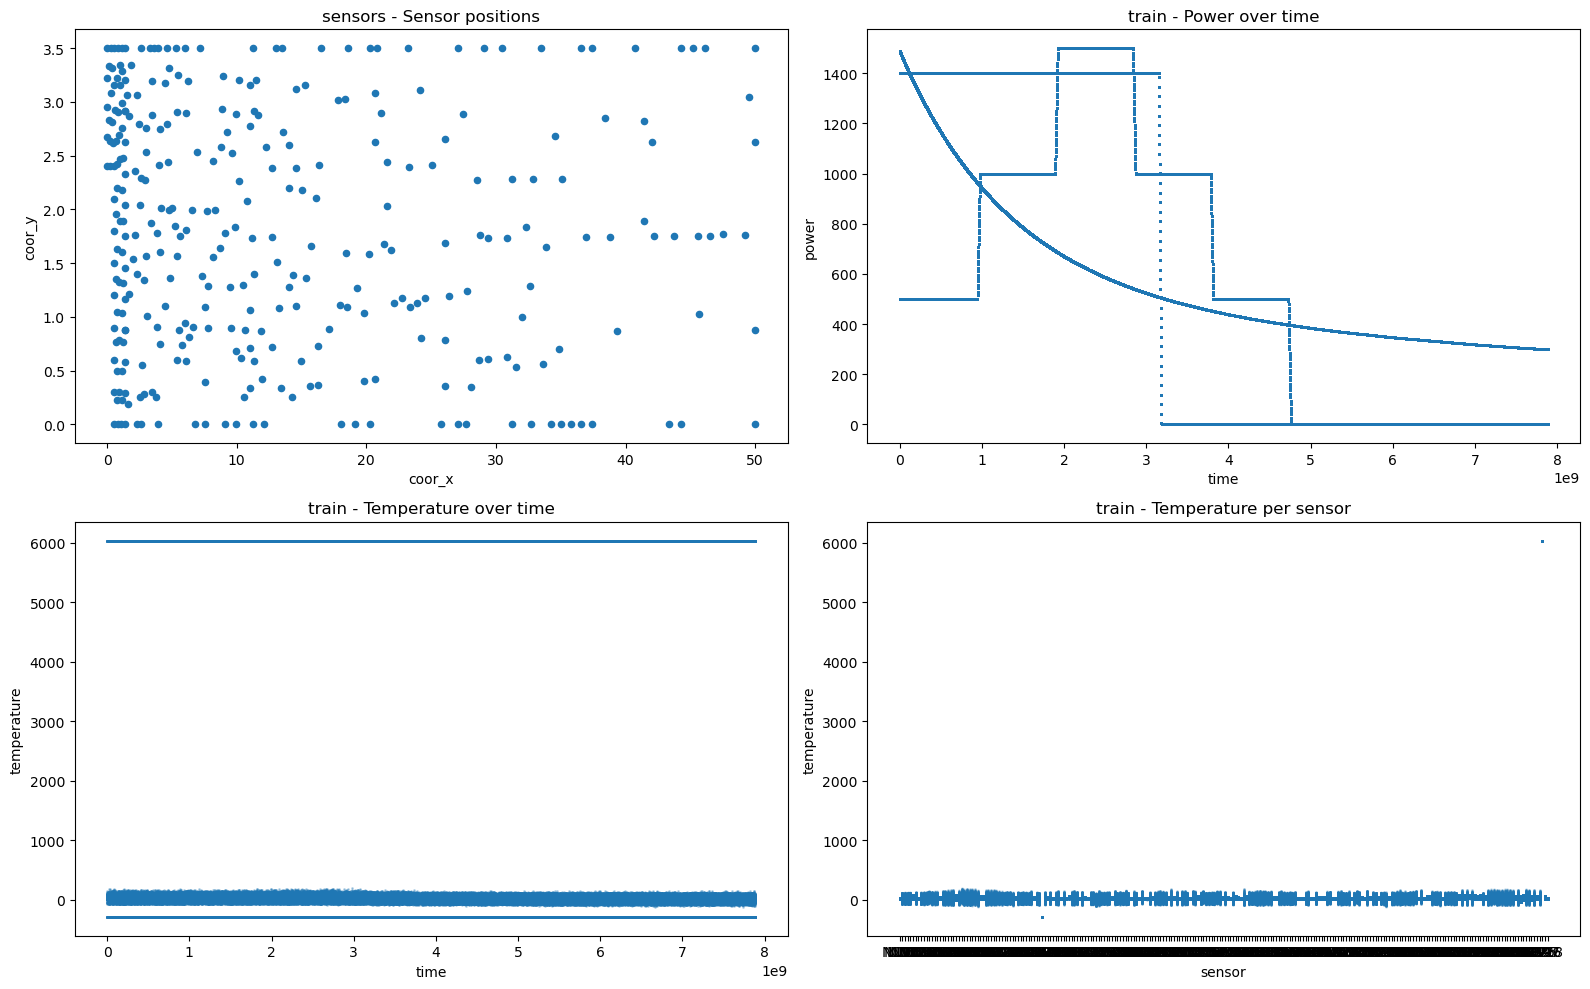

In [11]:
#visualization of various plots
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sensors.plot(kind='scatter', x='coor_x', y='coor_y', ax=axes[0,0], title='sensors - Sensor positions')
train.plot(kind='scatter', x='time', y='power', ax=axes[0,1], title='train - Power over time', s=1)
train.plot(kind='scatter', x='time', y='temperature', alpha=0.3, ax=axes[1,0], title='train - Temperature over time', s=1)
train.plot(kind='scatter', x='sensor', y='temperature', alpha=0.15, ax=axes[1,1], title='train - Temperature per sensor', s=1)

plt.tight_layout()
plt.show()

In [12]:
#finding the name of the two sensors which are very far from our expected values
neg_outlier = train[train['temperature'] == train['temperature'].min()]
pos_outlier = train[train['temperature'] == train['temperature'].max()]
print(neg_outlier, pos_outlier)

        sensor          time        power  temperature
483784    N277  0.000000e+00  1487.964722  -292.150848
483785    N277  8.640000e+05  1487.288818  -292.150848
483786    N277  1.728000e+06  1486.612915  -292.150848
483787    N277  2.592000e+06  1485.936890  -292.150848
483788    N277  3.456000e+06  1485.260986  -292.150848
...        ...           ...          ...          ...
4910859   N277  7.880458e+09     0.000000  -292.150848
4910860   N277  7.881322e+09     0.000000  -292.150848
4910861   N277  7.882186e+09     0.000000  -292.150848
4910862   N277  7.883050e+09     0.000000  -292.150848
4910863   N277  7.884000e+09     0.000000  -292.150848

[27384 rows x 4 columns]         sensor          time        power  temperature
2181592   N927  0.000000e+00  1487.964722  6039.049805
2181593   N927  8.640000e+05  1487.288818  6039.049805
2181594   N927  1.728000e+06  1486.612915  6039.049805
2181595   N927  2.592000e+06  1485.936890  6039.049805
2181596   N927  3.456000e+06  1485.2609

### Key Observations

<div style="text-align: justify;">
Through the exploratory data analysis, we identified several important characteristics 
of the dataset that will guide our preprocessing steps :

- **Missing values :** 99403 temperature values are missing across multiple sensors 
and will need to be imputed before training.

- **Outlier sensors :** Two sensors (N277 and N927) show clearly aberrant temperature 
values (below -292°C and above 6039°C) and will be removed entirely.

- **3 experimental modes :** The power-time plot reveals 3 distinct heating profiles, 
suggesting the data contains 3 separate experiments that should be treated independently.

- **Sensor positions :** The sensors are not evenly distributed in space, 
which means a simple global average would be biased when imputing missing values.

- **Temperature range :** Most sensors record temperatures between 14°C and 30°C, 
with a few reaching higher values close to the canister.
</div>

# 4. Preprocessing

We first preprocess our data structure. Remove some duplicate sensors, merge train and sensors to have everything on one dataset, drop the z_coor column which is not useful for us and add a column with the distances of each sensor to the canister (at coordinate (0,0)).

In [13]:
#we see there are duplicates in sensors
print(f'number of duplicate sensors: {sensors['sensor'].duplicated().sum()}')

number of duplicate sensors: 2


In [14]:
#drop duplicates
sensors_unique = sensors.drop_duplicates(subset='sensor')
print(f'number of unique sensors: {len(sensors_unique)}')

number of unique sensors: 323


In [15]:
train = train.merge(sensors_unique[['sensor', 'coor_x', 'coor_y', 'coor_z']], on='sensor', how='left')
train = train.drop(columns=['coor_z'])

test = test.merge(sensors_unique[['sensor', 'coor_x', 'coor_y', 'coor_z']], on='sensor', how='left')
test = test.drop(columns=['coor_z'])

In [16]:
# add feature
train['dist_r'] = np.sqrt(train['coor_x']**2 + train['coor_y']**2)
test['dist_r'] = np.sqrt(test['coor_x']**2 + test['coor_y']**2)

train.head()

,sensor,time,power,temperature,coor_x,coor_y,dist_r
0,N102,0.0,1487.964722,17.514429,46.131474,3.5,46.264053
1,N102,864000.0,1487.288818,17.820795,46.131474,3.5,46.264053
2,N102,1728000.0,1486.612915,17.573187,46.131474,3.5,46.264053
3,N102,2592000.0,1485.936890,16.513235,46.131474,3.5,46.264053
4,N102,3456000.0,1485.260986,16.303427,46.131474,3.5,46.264053


<div style="text-align: justify;">
The feature dist_r (radial distance from the canister center) was added as an engineered feature. 
Since heat diffusion follows an inverse relationship with distance, 
the radial distance is physically more meaningful than coor_x and coor_y separately. 
Adding dist_r improved the model's performance by providing 
a physically meaningful representation of the heat source proximity, 
allowing the model to better capture the spatial temperature distribution.
</div>

## 4.1 Missing values

In [17]:
#list of the missing values
missing_val = train[train['temperature'].isna()].index

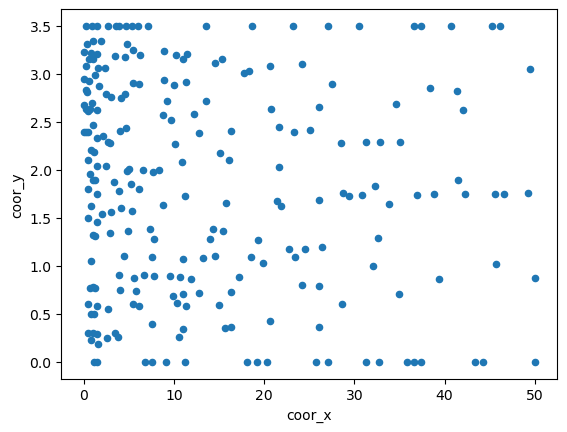

In [18]:
#see where the missing values are --> a bit everywhere
sensors_misval = train.loc[missing_val, 'sensor'].unique()
sensors_misval_coords = sensors[sensors['sensor'].isin(sensors_misval)]

sensors_misval_coords.plot(kind='scatter', x='coor_x', y='coor_y')
plt.show()

<div style="text-align: justify;">
We use linear interpolation grouped by sensor because the data is ordered 
chronologically. This preserves the temporal evolution of each sensor better 
than a global mean, which would ignore the time structure.
</div>

In [19]:
#For each sensor independently, replace missing temperature values using linear interpolation.
train['temperature'] = (
    train.groupby('sensor')['temperature']
    .transform(lambda x: x.interpolate(method='linear', limit_direction='both'))
)

In [20]:
#check that their are no more missing values
train.isna().sum() 

sensor         0
time           0
power          0
temperature    0
coor_x         0
coor_y         0
dist_r         0
dtype: int64

## 4.2 Manually remove some outliers

This will help us visualise our code better.

In [21]:
#remove the two extreme sensors which are completely useless. We remove them because their are only two, which is very few.
train = train[train["sensor"] != "N277"]
train = train[train["sensor"] != "N927"]
sensors = sensors[sensors["sensor"] != "N277"]
sensors = sensors[sensors["sensor"] != "N927"]

In [22]:
#control wether values are reasonable
print("Min température:", train['temperature'].min())
print("Max température:", train['temperature'].max())
print("Mean température:", train['temperature'].mean())

Min température: -119.05078
Max température: 186.7141
Mean température: 23.145048


<Axes: xlabel='sensor', ylabel='temperature'>

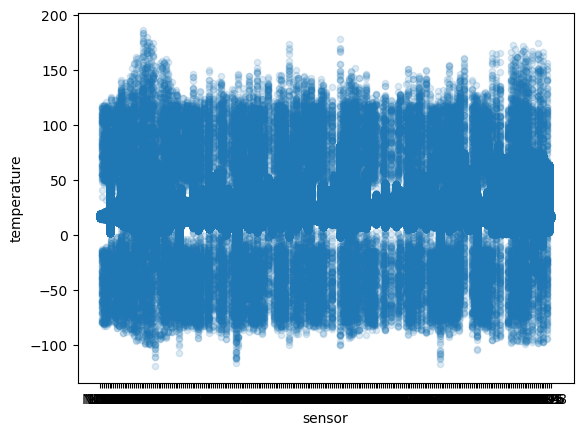

In [23]:
#Visualization after getting rid of 2 bad sensors --> better
train.plot(kind='scatter', x='sensor', y='temperature', alpha=0.15)

We now have a reasonable range of values. We still have lots of noise which we will clean later on.

## 4.3 Normalisation

<div style="text-align: justify;">
We normalize time and power using StandardScaler because the scales of the features differ 
greatly (billions vs 0-1500). This ensures that no feature dominates the model 
simply due to its magnitude.
</div>

In [24]:
features = ['time', 'power', 'coor_x', 'coor_y', 'dist_r']

scaler = StandardScaler()
train[features] = scaler.fit_transform(train[features])
test[features]  = scaler.transform(test[features])

print(train[features].describe())

               time         power        coor_x        coor_y        dist_r
count  6.572160e+06  6.572160e+06  6.572160e+06  6.572160e+06  6.572160e+06
mean   7.306779e-17 -8.247803e-17 -2.214175e-17  1.195655e-16 -4.428351e-17
std    1.000000e+00  1.000000e+00  1.000000e+00  1.000000e+00  1.000000e+00
min   -1.732045e+00 -1.055347e+00 -9.957756e-01 -1.666897e+00 -1.023057e+00
25%   -8.657853e-01 -1.055347e+00 -8.403575e-01 -8.692870e-01 -8.063352e-01
50%    1.327983e-04 -2.098822e-01 -3.490839e-01  5.826888e-03 -3.780498e-01
75%    8.660130e-01  8.463630e-01  5.941306e-01  8.908014e-01  5.791534e-01
max    1.731931e+00  1.797218e+00  2.670097e+00  1.513439e+00  2.709094e+00


## 4.4 Separation of modes

<div style="text-align: justify;">
The power-time plot reveals 3 distinct experimental modes. Since each sensor has 
27384 timesteps split into 3 equal blocks of 9128, we separate them by dividing 
the dataset into 3 equal parts of 2190720 rows each.
</div>

(2190720, 7) (2190720, 7) (2190720, 7)


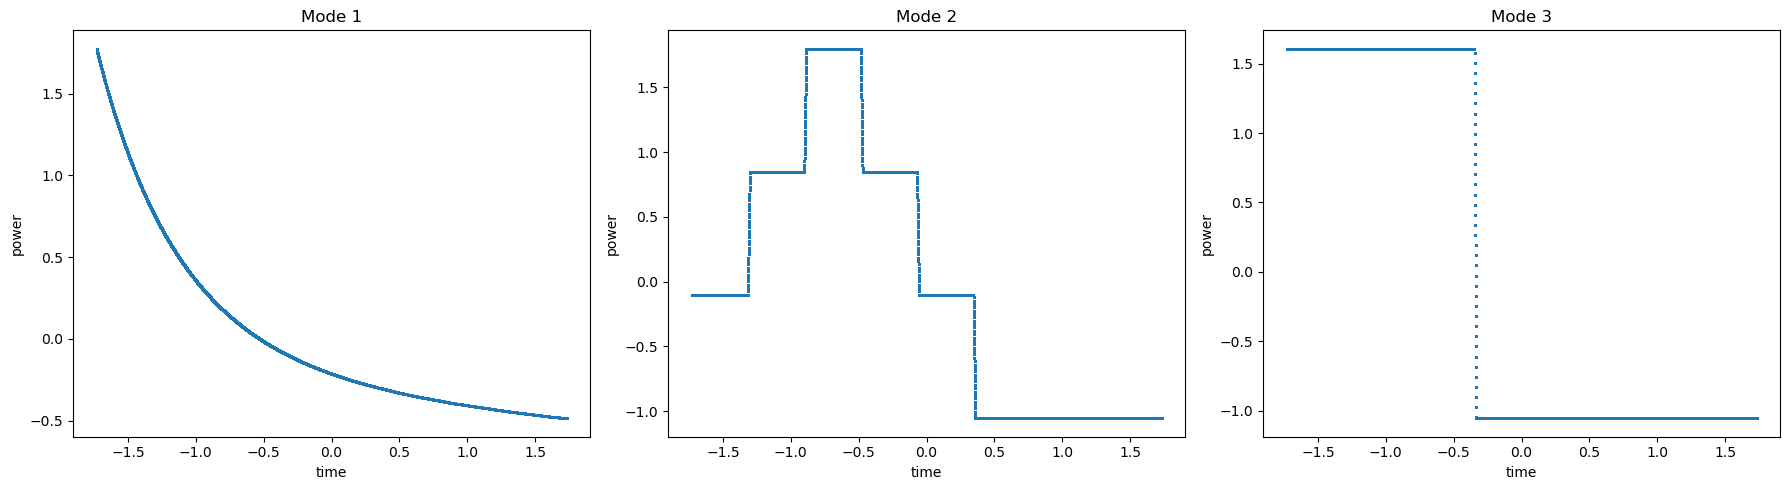

In [25]:
#seperation of three modes
BLOCK = len(train) // 3

mode1 = train.iloc[0       : BLOCK].copy()
mode2 = train.iloc[BLOCK   : 2*BLOCK].copy()
mode3 = train.iloc[2*BLOCK :].copy()

print(mode1.shape, mode2.shape, mode3.shape)

# Visualization of the three modes
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

mode1.plot(kind='scatter', x='time', y='power', ax=axes[0], title='Mode 1', s=1)
mode2.plot(kind='scatter', x='time', y='power', ax=axes[1], title='Mode 2', s=1)
mode3.plot(kind='scatter', x='time', y='power', ax=axes[2], title='Mode 3', s=1)

plt.tight_layout()
plt.show()

In [26]:
#same for test set
BLOCK = len(test) // 3

test_mode1 = test.iloc[0       : BLOCK].copy()
test_mode2 = test.iloc[BLOCK   : 2*BLOCK].copy()
test_mode3 = test.iloc[2*BLOCK :].copy()

print(test_mode1.shape, test_mode2.shape, test_mode3.shape)

(730160, 6) (730160, 6) (730160, 6)


## 4.5 Outliers

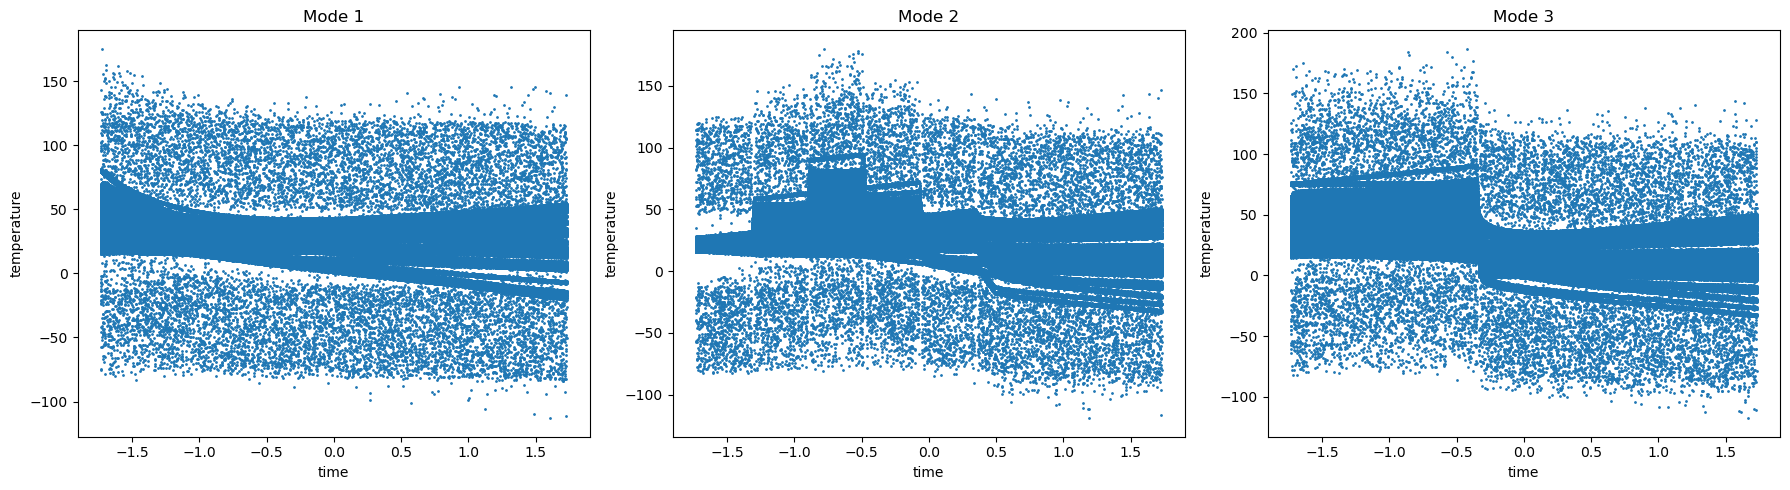

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

mode1.plot(kind='scatter', x='time', y='temperature', ax=axes[0], title='Mode 1', s=1)
mode2.plot(kind='scatter', x='time', y='temperature', ax=axes[1], title='Mode 2', s=1)
mode3.plot(kind='scatter', x='time', y='temperature', ax=axes[2], title='Mode 3', s=1)

plt.tight_layout()
plt.show()

In [28]:
def replace_outliers_mode1(
    df: pd.DataFrame,  
    threshold: int = 3):
    '''Creats a curve that fits the data best and replace values to far from it
    Args:
        df: mode1/2/3
        threshold: distance permitted to qualify a value as outlier
    '''

    time = df['time'].to_numpy()
    temp = df['temperature'].to_numpy()
    
    degree = 3
    coeffs = np.polyfit(time, temp, degree)
    trend = np.polyval(coeffs, time)
    
    residuals = temp - trend
    outlier_mask = np.abs(stats.zscore(residuals)) >= threshold
    
    temp_replaced = temp.copy()
    temp_replaced[outlier_mask] = trend[outlier_mask]
    
    df = df.copy()
    df['temperature'] = temp_replaced
    return df


def replace_outliers_mode2(
    df: pd.DataFrame, 
    threshold: int = 3):
    '''Seperates graph in eight parts and replaces values that are to far from each part
    Args:
        df: mode1/2/3
        threshold: distance permitted to qualify a value as outlier
    '''

    power_levels = pd.cut(df['power'], bins=8)
    
    def replace_group(x):
        if len(x) > 1:
            outlier_mask = np.abs(stats.zscore(x, ddof=0)) >= threshold
            x = x.copy()
            x[outlier_mask] = x[~outlier_mask].mean()
        return x
    
    df = df.copy()
    df['temperature'] = df.groupby(power_levels, observed=True)['temperature'].transform(replace_group)
    return df


def replace_outliers_mode3(
    df: pd.DataFrame, 
    threshold: int = 3):
    '''Seperates graph in two parts and replaces values that are to far from each part
    Args:
        df: mode1/2/3
        threshold: distance permitted to qualify a value as outlier
    '''

    power_levels = pd.cut(df['power'], bins=2)
    
    def replace_group(x):
        if len(x) > 1:
            outlier_mask = np.abs(stats.zscore(x, ddof=0)) >= threshold
            x = x.copy()
            x[outlier_mask] = x[~outlier_mask].mean()
        return x
    
    df = df.copy()
    df['temperature'] = df.groupby(power_levels, observed=True)['temperature'].transform(replace_group)
    return df


OUTLIER_FN = {
    1: replace_outliers_mode1,
    2: replace_outliers_mode2,
    3: replace_outliers_mode3,
}


def clean_mode(
    mode_df: pd.DataFrame, 
    mode_id: int, 
    threshold: int=3):
    '''Divides the DataFrame into 3 temporal segments, applies the outlier replacement
    function corresponding to mode_id on each (sensor, segment) group, then returns 
    the cleaned DataFrame with its original index.
    Args:
        mode_df: mode1/2/3
        mode_id: 1/2/3 (corresponding to mode)
        threshold: distance permitted to qualify a value as outlier
    '''

    outlier_fn = OUTLIER_FN[mode_id]
    
    return (
        mode_df.groupby(['sensor', pd.qcut(range(len(mode_df)), q=3, labels=['t1', 't2', 't3'])])
        .apply(lambda df: outlier_fn(df, threshold), include_groups=False)
        .reset_index(level=[0, 1], drop=True)
        .reset_index()
        .rename(columns={'index': 'sensor'})
    )

mode1_clean = clean_mode(mode1, mode_id=1)
mode2_clean = clean_mode(mode2, mode_id=2)
mode3_clean = clean_mode(mode3, mode_id=3)

train_clean = pd.concat([mode1_clean, mode2_clean, mode3_clean], ignore_index=True)

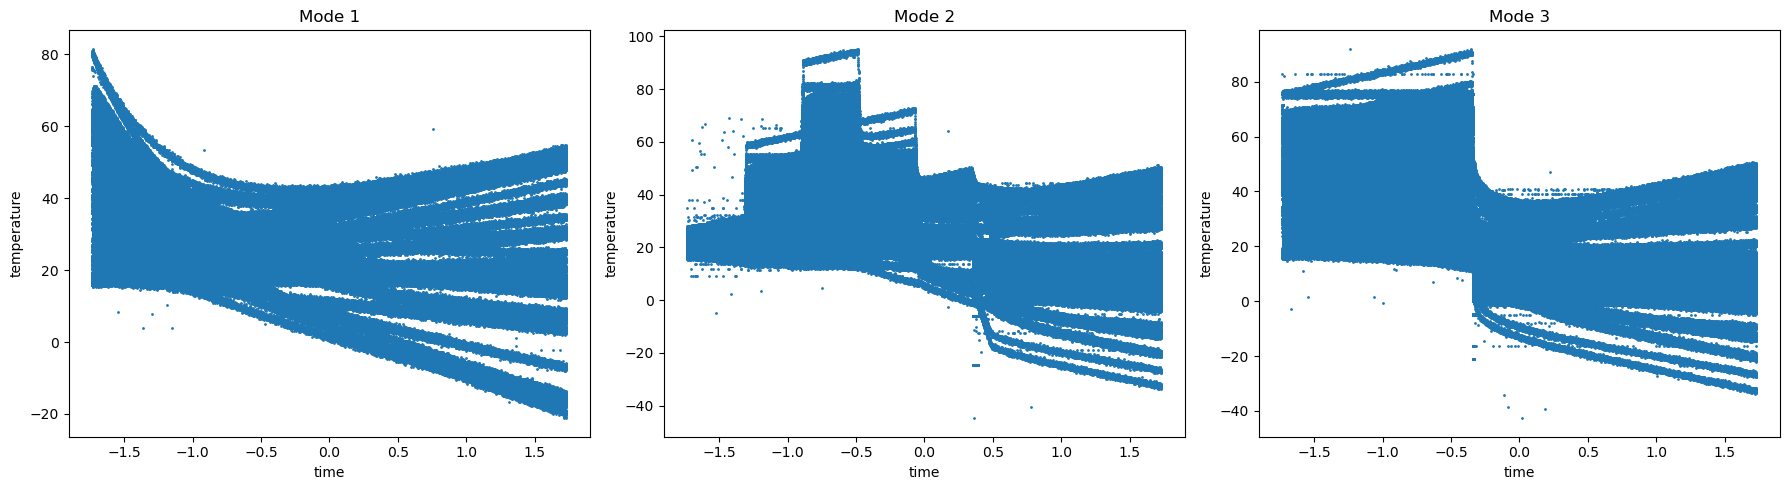

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

mode1_clean.plot(kind='scatter', x='time', y='temperature', ax=axes[0], title='Mode 1', s=1)
mode2_clean.plot(kind='scatter', x='time', y='temperature', ax=axes[1], title='Mode 2', s=1)
mode3_clean.plot(kind='scatter', x='time', y='temperature', ax=axes[2], title='Mode 3', s=1)

plt.tight_layout()
plt.show()

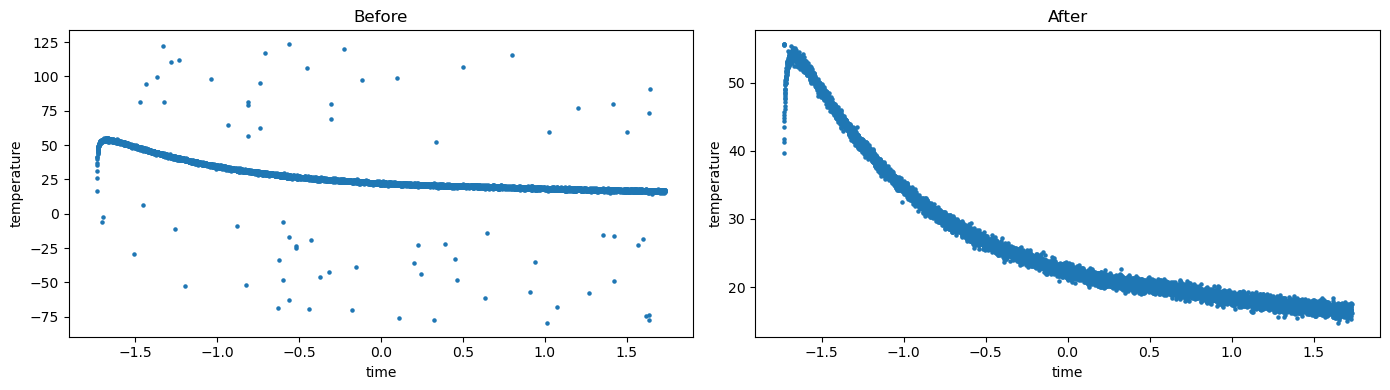

In [30]:
#visualization of one sensor to have an idea of what it does
sens = mode1[mode1['sensor'] == 'N210']
sens_clean = replace_outliers_mode1(sens)

# Plot to compare
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sens.plot(kind='scatter', x='time', y='temperature', ax=axes[0], title='Before', s=5)
sens_clean.plot(kind='scatter', x='time', y='temperature', ax=axes[1], title='After', s=5)
plt.tight_layout()
plt.show()

After going randomly through some sensors, we identified some sensor drift. We will remove eight of them. 

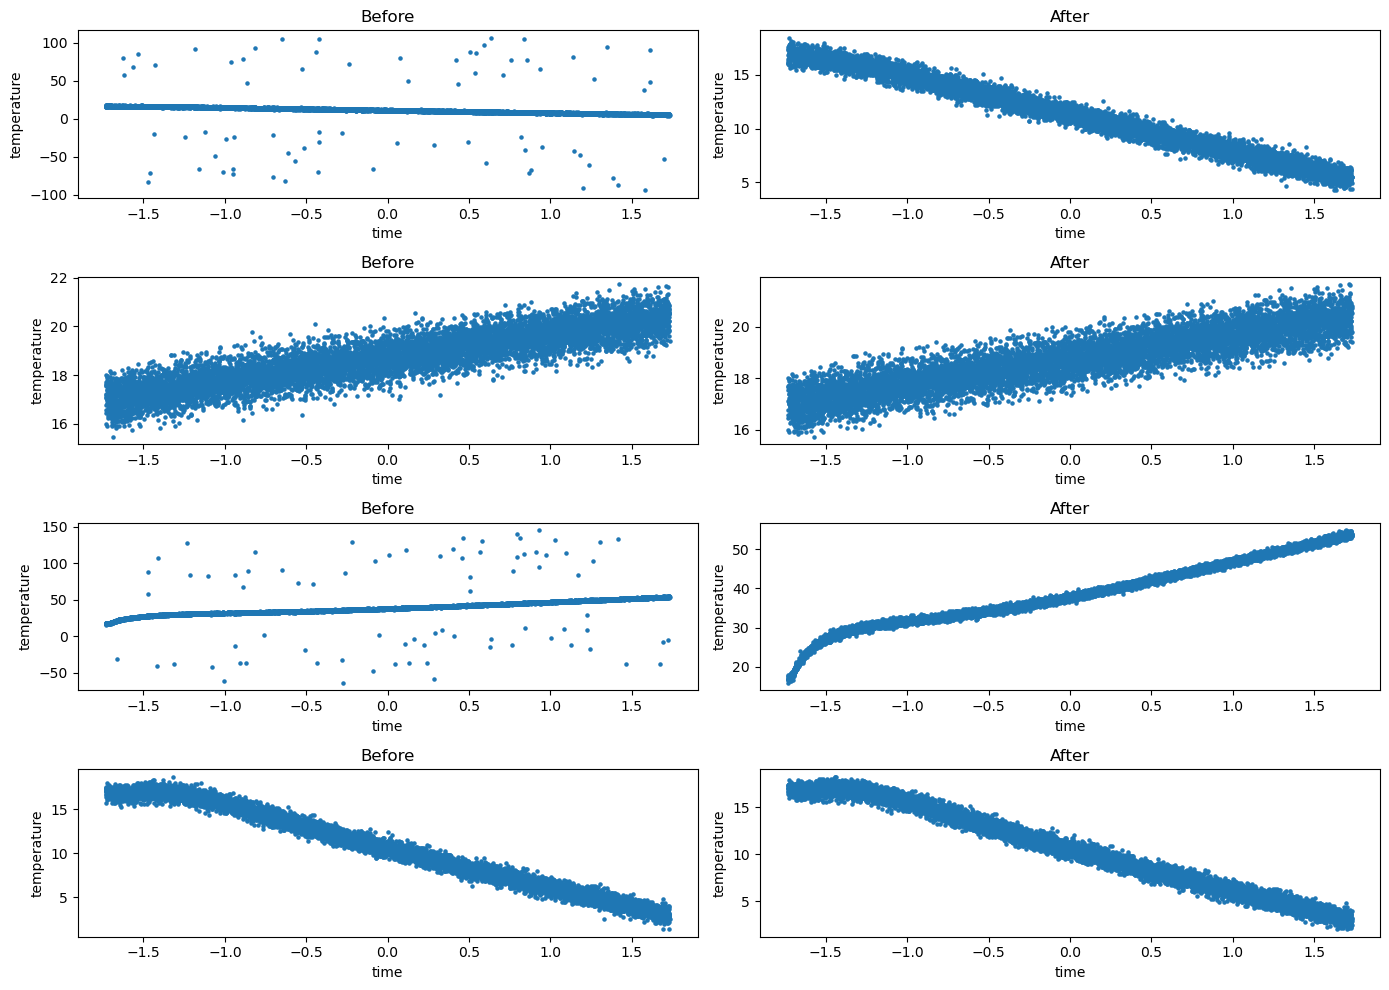

In [31]:
#visualisation of four sensor drift cases
sensor1 = mode1[mode1['sensor'] == 'N276']
sensor1_clean = replace_outliers_mode1(sensor1)
sensor2 = mode1[mode1['sensor'] == 'N838']
sensor2_clean = replace_outliers_mode1(sensor2)
sensor3 = mode1[mode1['sensor'] == 'N749']
sensor3_clean = replace_outliers_mode1(sensor3)
sensor4 = mode1[mode1['sensor'] == 'N436']
sensor4_clean = replace_outliers_mode1(sensor4)

fig, axes = plt.subplots(4, 2, figsize=(14, 10))
sensor1.plot(kind='scatter', x='time', y='temperature', ax=axes[0, 0], title='Before', s=5)
sensor1_clean.plot(kind='scatter', x='time', y='temperature', ax=axes[0, 1], title='After', s=5)
sensor2.plot(kind='scatter', x='time', y='temperature', ax=axes[1, 0], title='Before', s=5)
sensor2_clean.plot(kind='scatter', x='time', y='temperature', ax=axes[1, 1], title='After', s=5)
sensor3.plot(kind='scatter', x='time', y='temperature', ax=axes[2, 0], title='Before', s=5)
sensor3_clean.plot(kind='scatter', x='time', y='temperature', ax=axes[2, 1], title='After', s=5)
sensor4.plot(kind='scatter', x='time', y='temperature', ax=axes[3, 0], title='Before', s=5)
sensor4_clean.plot(kind='scatter', x='time', y='temperature', ax=axes[3, 1], title='After', s=5)
plt.tight_layout()
plt.show()

In [32]:
#remove eight sensor drifts.
mode1_clean = mode1_clean[mode1_clean["sensor"] != "N838"]
mode1_clean = mode1_clean[mode1_clean["sensor"] != "N301"]
mode1_clean = mode1_clean[mode1_clean["sensor"] != "N749"]
mode1_clean = mode1_clean[mode1_clean["sensor"] != "N276"]
mode1_clean = mode1_clean[mode1_clean["sensor"] != "N821"]
mode1_clean = mode1_clean[mode1_clean["sensor"] != "N165"]
mode1_clean = mode1_clean[mode1_clean["sensor"] != "N121"]
mode1_clean = mode1_clean[mode1_clean["sensor"] != "N436"]

mode2_clean = mode2_clean[mode2_clean["sensor"] != "N838"]
mode2_clean = mode2_clean[mode2_clean["sensor"] != "N301"]
mode2_clean = mode2_clean[mode2_clean["sensor"] != "N749"]
mode2_clean = mode2_clean[mode2_clean["sensor"] != "N276"]
mode2_clean = mode2_clean[mode2_clean["sensor"] != "N821"]
mode2_clean = mode2_clean[mode2_clean["sensor"] != "N165"]
mode2_clean = mode2_clean[mode2_clean["sensor"] != "N121"]
mode2_clean = mode2_clean[mode2_clean["sensor"] != "N436"]

mode3_clean = mode3_clean[mode3_clean["sensor"] != "N838"]
mode3_clean = mode3_clean[mode3_clean["sensor"] != "N301"]
mode3_clean = mode3_clean[mode3_clean["sensor"] != "N749"]
mode3_clean = mode3_clean[mode3_clean["sensor"] != "N276"]
mode3_clean = mode3_clean[mode3_clean["sensor"] != "N821"]
mode3_clean = mode3_clean[mode3_clean["sensor"] != "N165"]
mode3_clean = mode3_clean[mode3_clean["sensor"] != "N121"]
mode3_clean = mode3_clean[mode3_clean["sensor"] != "N436"]

sensors_unique = sensors_unique[sensors_unique["sensor"] != "N838"]
sensors_unique = sensors_unique[sensors_unique["sensor"] != "N301"]
sensors_unique = sensors_unique[sensors_unique["sensor"] != "N749"]
sensors_unique = sensors_unique[sensors_unique["sensor"] != "N276"]
sensors_unique = sensors_unique[sensors_unique["sensor"] != "N821"]
sensors_unique = sensors_unique[sensors_unique["sensor"] != "N165"]
sensors_unique = sensors_unique[sensors_unique["sensor"] != "N121"]
sensors_unique = sensors_unique[sensors_unique["sensor"] != "N436"]

# 5. Model Training

## 5.1 KNN

In [33]:
#Transforms data into numpy arrays and splits it into a train, val and test set
def preprocess_data(
    df: pd.DataFrame,
    label: str,
    train_size: float = 0.6,
    val_size: float = 0.2,
    seed: Optional[int] = None,
) -> Tuple[
    np.ndarray,
    np.ndarray,
    np.ndarray,
    np.ndarray,
    np.ndarray,
    np.ndarray,
    List[str],
]:
    df = df.sample(frac=1, random_state=seed)

    train, val, test = (
        df[: int(len(df) * train_size)],
        df[int(len(df) * train_size) : int(len(df) * (train_size + val_size))],
        df[int(len(df) * (train_size + val_size)) :],
    )

    X_train = train.drop(columns=label).to_numpy()
    X_val = val.drop(columns=label).to_numpy()
    X_test = test.drop(columns=label).to_numpy()

    y_train = train[label].to_numpy()
    y_val = val[label].to_numpy()
    y_test = test[label].to_numpy()

    return X_train, y_train, X_val, y_val, X_test, y_test

In [34]:
def predict(
    samples: np.ndarray, 
    X: np.ndarray,
    y: np.ndarray,
    k: int = 1):
    '''find indices of k neighbors
    '''
    
    tree = KDTree(X)                    
    _, indices = tree.query(samples, k=k, workers=-1)
    
    if k == 1:
        return y[indices].flatten()
    return np.mean(y[indices], axis=1)

In [35]:
def rmse(
    labels_gt: np.ndarray,
    labels_pred: np.ndarray):
    '''calculatrs rmse
    '''

    rmse = np.sqrt(np.mean((labels_gt - labels_pred) ** 2))

    return rmse

Predictions when training on the whole train dataset (i.e. without seperating into modes)

In [36]:
X_train, y_train, X_val, y_val, X_test, y_test = preprocess_data(df=train_clean.drop(columns=['power']), label="temperature", train_size=0.6, val_size=0.2, seed=42)

In [37]:
y_pred_train = predict(X_val, X_train, y_train, k=4)

In [38]:
#rmse for the prediction without sepatating our data by their powers
print(f'rmse without seperation in modes: {rmse(y_val, y_pred_train)}')

rmse without seperation in modes: 0.7215412855148315


Predictions when seperating into modes (much better results)

In [39]:
X_train1, y_train1, X_val1, y_val1, X_test1, y_test1 = preprocess_data(df=mode1_clean.drop(columns=['power']), label="temperature", train_size=0.6, val_size=0.2, seed=42)
X_train2, y_train2, X_val2, y_val2, X_test2, y_test2 = preprocess_data(df=mode2_clean.drop(columns=['power']), label="temperature", train_size=0.6, val_size=0.2, seed=42)
X_train3, y_train3, X_val3, y_val3, X_test3, y_test3 = preprocess_data(df=mode3_clean.drop(columns=['power']), label="temperature", train_size=0.6, val_size=0.2, seed=42)

In [40]:
y_pred_mode1 = predict(X_test1, X_train1, y_train1, k=4)
y_pred_mode2 = predict(X_test2, X_train2, y_train2, k=4)
y_pred_mode3 = predict(X_test3, X_train3, y_train3, k=4)

y_test_modes = np.concatenate([y_test1, y_test2, y_test3])
y_pred_modes = np.concatenate([y_pred_mode1, y_pred_mode2, y_pred_mode3])

In [41]:
print(f'rmse mode1: {rmse(y_test1, y_pred_mode1)}')
print(f'rmse mode2: {rmse(y_test2, y_pred_mode2)}')
print(f'rmse mode3: {rmse(y_test3, y_pred_mode3)}')

rmse mode1: 0.6070718169212341
rmse mode2: 0.679649829864502
rmse mode3: 0.8350356221199036


In [42]:
print(f'rmse concactenated: {rmse(y_test_modes, y_pred_modes)}')

rmse concactenated: 0.7136162519454956


To find which k to choose, we plot the rmse for k of 1 to 10 and look at the graph to know which one is the best

In [43]:
#find rmse for k values between 1 and 10
k_values = []
accs = []
for i in range(1, 10):
    acc = rmse(y_val1, predict(X_val1, X_train1, y_train1, k=i))
    k_values.append(i)
    accs.append(acc)

C:\Users\alice\AppData\Local\Temp\ipykernel_17036\532327246.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


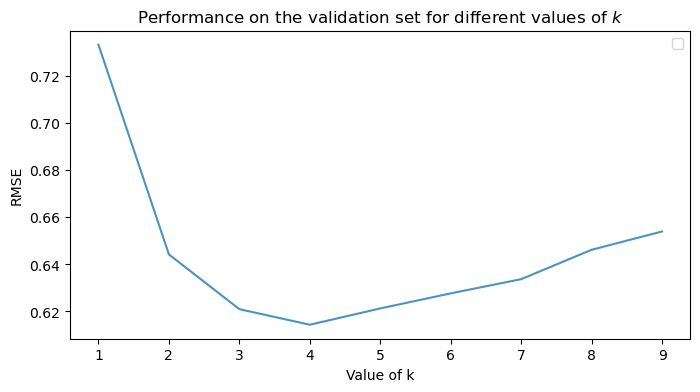

In [45]:
#plot rmse in function of k
plt.figure(figsize=(8,4), dpi=100)
plt.plot(k_values, accs, alpha=0.8)
plt.xlabel("Value of k")
plt.ylabel("RMSE")
plt.legend()
plt.title("Performance on the validation set for different values of $k$")
plt.show()

Test our model on the text dataset that we seperated in 3 modes: test1, test2, test3

In [93]:
test1 = test_mode1.drop(columns=['power', 'sensor']).to_numpy()
test2 = test_mode2.drop(columns=['power', 'sensor']).to_numpy()
test3 = test_mode3.drop(columns=['power', 'sensor']).to_numpy()

X_mode1 = mode1_clean.drop(columns=['power', 'sensor', 'temperature']).to_numpy()
X_mode2 = mode2_clean.drop(columns=['power', 'sensor', 'temperature']).to_numpy()
X_mode3 = mode3_clean.drop(columns=['power', 'sensor', 'temperature']).to_numpy()

y_mode1 = mode1_clean['temperature'].to_numpy()
y_mode2 = mode2_clean['temperature'].to_numpy()
y_mode3 = mode3_clean['temperature'].to_numpy()

In [95]:
y_pred_mode1 = predict(test1, X_mode1, y_mode1, k=4)
y_pred_mode2 = predict(test2, X_mode2, y_mode2, k=4)
y_pred_mode3 = predict(test3, X_mode3, y_mode3, k=4)

y_pred = np.concatenate([y_pred_mode1, y_pred_mode2, y_pred_mode3])

# 5.2 Neural Network

<div style="text-align: justify;">
After the KNN, we decided to train a Multi-Layer Perceptron (MLP) separately on each of the 3 experimental 
modes. This approach achieved a weighted RMSE of 1.77 on the Kaggle leaderboard, 
significantly outperforming the baseline model, and represents our best submission.
</div>

In [28]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(5, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
    
    def forward(self, x):
        return self.network(x)

In [29]:
from sklearn.model_selection import train_test_split
def train_mlp(
    X_train, 
    y_train, 
    X_val, 
    y_val, 
    n_epochs=20):
    """train a MLP on a given mode and return the trained model.
    """
    
    X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
    y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1).to(device)
    X_val_t = torch.tensor(X_val, dtype=torch.float32).to(device)
    y_val_t = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1).to(device)
    
    dataset = TensorDataset(X_train_t, y_train_t)
    loader = DataLoader(dataset, batch_size=4096, shuffle=True)
    
    model = MLP().to(device)
    #optimizer and scheduler
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
    criterion = nn.MSELoss()

    best_rmse = float('inf')
    best_model_state = None

    for epoch in range(n_epochs):
        model.train()
        for X_batch, y_batch in loader:
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            optimizer.step()
        
        model.eval()
        with torch.no_grad():
            rmse = torch.sqrt(criterion(model(X_val_t), y_val_t)).item()
        
        scheduler.step(rmse)
        
        if rmse < best_rmse:
            best_rmse = rmse
            best_model_state = model.state_dict().copy()
        
        print(f"Epoch {epoch+1}/{n_epochs} | RMSE Val: {rmse:.4f} | LR: {optimizer.param_groups[0]['lr']:.2e}")

    model.load_state_dict(best_model_state)
    print(f"Best RMSE Val: {best_rmse:.4f}")
    return model

features = ['time', 'power', 'coor_x', 'coor_y', 'dist_r']
target = 'temperature'

print("=== MODE 1 ===")
X1 = mode1_clean[features].values
y1 = mode1_clean[target].values
X1_train, X1_val, y1_train, y1_val = train_test_split(X1, y1, train_size=0.8, random_state=42)
model1 = train_mlp(X1_train, y1_train, X1_val, y1_val)

print("=== MODE 2 ===")
X2 = mode2_clean[features].values
y2 = mode2_clean[target].values
X2_train, X2_val, y2_train, y2_val = train_test_split(X2, y2, train_size=0.8, random_state=42)
model2 = train_mlp(X2_train, y2_train, X2_val, y2_val)

print("=== MODE 3 ===")
X3 = mode3_clean[features].values
y3 = mode3_clean[target].values
X3_train, X3_val, y3_train, y3_val = train_test_split(X3, y3, train_size=0.8, random_state=42)
model3 = train_mlp(X3_train, y3_train, X3_val, y3_val)

=== MODE 1 ===
Epoch 1/20 | RMSE Val: 7.5608 | LR: 1.00e-04
Epoch 2/20 | RMSE Val: 6.5152 | LR: 1.00e-04
Epoch 3/20 | RMSE Val: 5.8575 | LR: 1.00e-04
Epoch 4/20 | RMSE Val: 5.6014 | LR: 1.00e-04
Epoch 5/20 | RMSE Val: 5.4603 | LR: 1.00e-04
Epoch 6/20 | RMSE Val: 5.3372 | LR: 1.00e-04
Epoch 7/20 | RMSE Val: 5.2317 | LR: 1.00e-04
Epoch 8/20 | RMSE Val: 5.1436 | LR: 1.00e-04
Epoch 9/20 | RMSE Val: 5.0747 | LR: 1.00e-04
Epoch 10/20 | RMSE Val: 5.0155 | LR: 1.00e-04
Epoch 11/20 | RMSE Val: 4.9636 | LR: 1.00e-04
Epoch 12/20 | RMSE Val: 4.9136 | LR: 1.00e-04
Epoch 13/20 | RMSE Val: 4.8696 | LR: 1.00e-04
Epoch 14/20 | RMSE Val: 4.8298 | LR: 1.00e-04
Epoch 15/20 | RMSE Val: 4.7949 | LR: 1.00e-04
Epoch 16/20 | RMSE Val: 4.7566 | LR: 1.00e-04
Epoch 17/20 | RMSE Val: 4.7240 | LR: 1.00e-04
Epoch 18/20 | RMSE Val: 4.6905 | LR: 1.00e-04
Epoch 19/20 | RMSE Val: 4.6613 | LR: 1.00e-04
Epoch 20/20 | RMSE Val: 4.6352 | LR: 1.00e-04
Best RMSE Val: 4.6352
=== MODE 2 ===
Epoch 1/20 | RMSE Val: 10.5249 | LR: 

In [30]:
def predict_mlp(
    model, 
    test_df, 
    features):
    """Predict temperatures for a given test dataframe using the provided model.
    """
    
    model.eval()
    X = torch.tensor(test_df[features].values, dtype=torch.float32).to(device)
    with torch.no_grad():
        return model(X).cpu().numpy().flatten()

y_pred1 = predict_mlp(model1, test_mode1, features)
y_pred2 = predict_mlp(model2, test_mode2, features)
y_pred3 = predict_mlp(model3, test_mode3, features)

y_pred = np.concatenate([y_pred1, y_pred2, y_pred3])
print(f"Total predictions: {len(y_pred)}")
print(f"Min: {y_pred.min():.2f}, Max: {y_pred.max():.2f}")

Total predictions: 2190480
Min: -1.29, Max: 77.66


# SETUP FOR SUBMISSION (LEADERBOARD)

In [31]:
submission = pd.DataFrame({
   "Id": np.arange(len(test), dtype=int),
   "temperature": y_pred,
})
assert list(submission.columns) == ["Id", "temperature"]
assert len(submission) == len(test)
assert (submission["Id"].to_numpy() == np.arange(len(test))).all()
assert np.isfinite(submission["temperature"]).all()
assert submission.isna().sum().sum() == 0
submission.to_csv("submission.csv", index=False)
print("Saved submission.csv")


Saved submission.csv
